In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_circles, load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize']=(6, 4)

In [2]:
# simple linearly separable dataset

X_lin, y_lin= make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    random_state=42
)

y_lin[:10] # see first 10

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0])

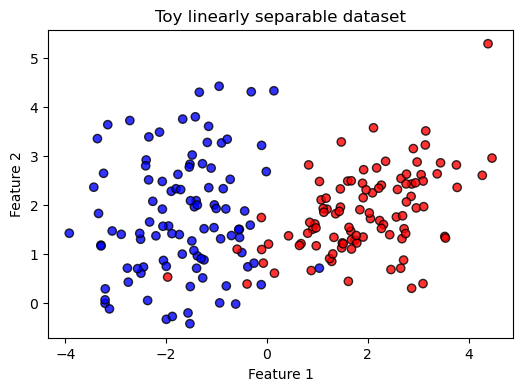

In [3]:
# visualise the toy dataset
plt.scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, cmap='bwr', edgecolors='k', alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Toy linearly separable dataset')
plt.show()

In [4]:
X_train, X_test, y_train, y_test= train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [5]:
svm_linear= SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [6]:
y_pred= svm_linear.predict(X_test_scaled)
acc= accuracy_score(y_test, y_pred)
acc

0.975

In [7]:
# helper function to plot decision boundary for 2D data
def plot_decision_boundary(model, X, y, title='Decesion boundary'):
    x_min, x_max= X[:, 0].min()- 1, X[:, 0].max()+ 1
    y_min, y_max= X[:, 1].min()- 1, X[:, 1].max()+ 1
    xx, yy =np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid= np.c_[xx.ravel(), yy.ravel()]
    Z= model.predict(grid)
    Z= Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.8)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

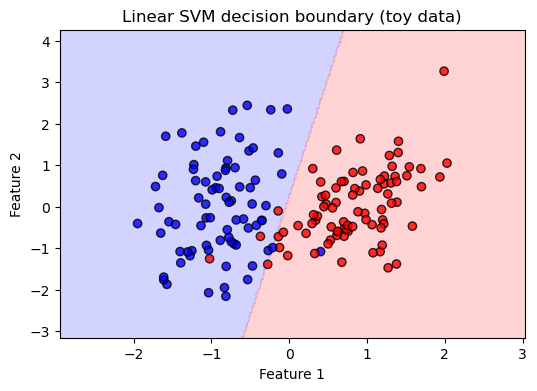

In [9]:
# call helper function for liner SVM
plot_decision_boundary(svm_linear, X_train_scaled, y_train, title='Linear SVM decision boundary (toy data)')